In [1]:
import pickle
with open("pre_split_data.pkl", "rb") as f:
    X, y, cat_cols, num_cols = pickle.load(f)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# CV target encoding
def target_encode_cv(X, y, column, n_splits=5):
    # use cross validation for target encoding 
    encoded = pd.Series(index=X.index, dtype=float)
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        # Compute mean target per category on train fold
        means = y_train_fold.groupby(X_train_fold[column]).mean()
        # Map validation fold
        encoded.iloc[val_idx] = X_val_fold[column].map(means)
    # Fill unseen categories (rare) with global mean
    encoded.fillna(y.mean(), inplace=True)
    return encoded

X_train_xgb = X_train[num_cols].copy()
X_test_xgb = X_test[num_cols].copy()

for col in cat_cols:
    if X_train[col].nunique() > 10:
        # CV target encoding for training
        X_train_xgb[col] = target_encode_cv(X_train, y_train, col)
        
        # Full-train target encoding for test set
        means = y_train.groupby(X_train[col]).mean()
        X_test_xgb[col] = X_test[col].map(means)
        # Fill unseen categories with global mean
        X_test_xgb.fillna({col:y_train.mean()}, inplace=True)
    else:
        # Frequency encoding for low-cardinality features
        freq = X_train[col].value_counts() / len(X_train)
        X_train_xgb[col] = X_train[col].map(freq)
        X_test_xgb[col] = X_test[col].map(freq).fillna(0)

# Train XGBoost
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight = scale_pos_weight,
    eval_metric='logloss'
)
xgb.fit(X_train_xgb, y_train)

y_pred_xgb = xgb.predict(X_test_xgb)
y_prob_xgb = xgb.predict_proba(X_test_xgb)[:,1]



=== XGBoost ===
Accuracy: 0.879925622150335
ROC AUC: 0.9531059984293335
F1 score: 0.4815222173339199


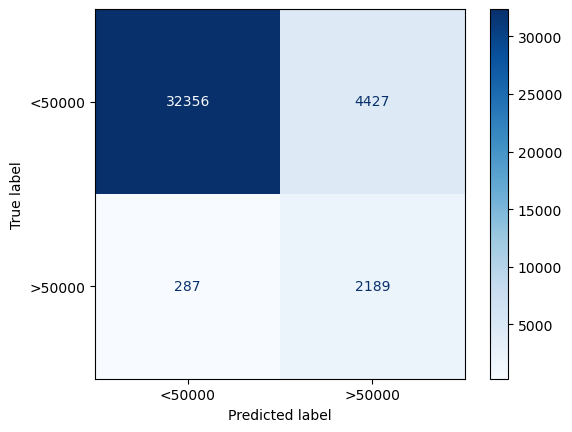

In [12]:
print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))
print("F1 score:", f1_score(y_test, y_pred_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=['<50000', '>50000'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

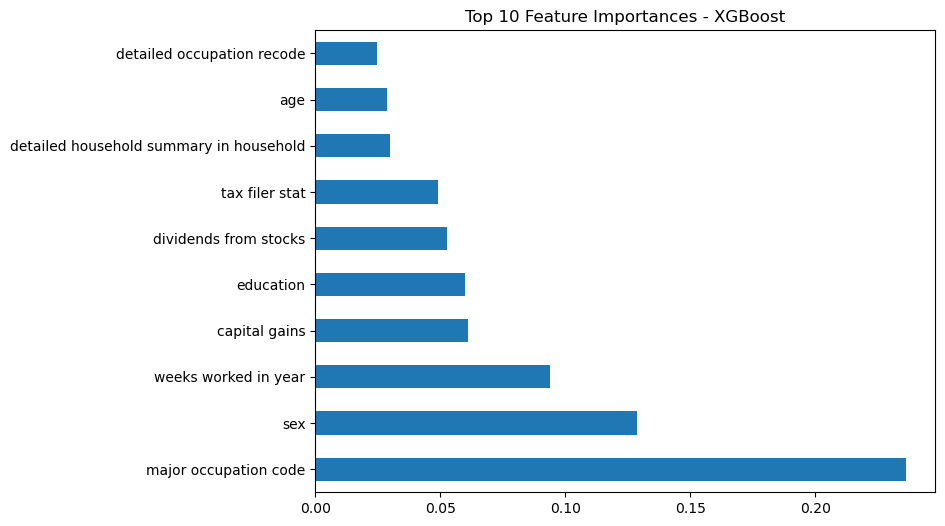

In [14]:

# ---------- 6. Feature importance ----------
import matplotlib.pyplot as plt

feat_importances = pd.Series(xgb.feature_importances_, index=X_train_xgb.columns)
feat_importances.nlargest(10).plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Feature Importances - XGBoost")
plt.show()



In [ ]:
print(cm)

Initial XGBoost uses the entire training set. 
Prediction were made using a default threshold of 0.5. 
The accuracy (0.9573855676405411) and AUC-ROC (0.9540701464560282) were high but the F1 score is low (0.5914529914529915). 
Confusion matrix [[36375   408],[ 1265  1211]] shows that the true positive rate (TP/P) is under 50%. 
There are a few things to do about this: \
- increase positive label weight
- adjust classification threshold
- hyperparameter tuning

By incorporating ratio of postive to negative in labels into XGBoost training (scale_pos_weight), TP rate increased significantly but precision dropped significantly, causing F1 score to drop under 0.5.
Confusion matrix [[32356  4427],[  287  2189]]. 

We tune the threshold by testing 100 thresholds between 0.1 and 0.9 to find the treshold that maximizes F1 score (0.8272).
With the new thresholds, confusion matrix is [[35589  1194],[  832  1644]]


[0.2791578222706672, 0.28499325077762777, 0.2910465674507921, 0.2971098975271522, 0.30237797246558196, 0.30754512405127876, 0.3126216111039045, 0.3176175382989963, 0.32250268528464016, 0.32732732732732733, 0.33201581027667987, 0.33610016882386046, 0.34096764958488407, 0.34551929646049856, 0.35069829306140543, 0.354729982772826, 0.3584376185058779, 0.3629230769230769, 0.3660436137071651, 0.3692720246076189, 0.37376, 0.37808529578376626, 0.3822637488730432, 0.38645418326693226, 0.38973240499958056, 0.3930116190314647, 0.39650295705836974, 0.39965397923875434, 0.4030438205195487, 0.4065730188179168, 0.40986242629980346, 0.4134876152594468, 0.417100575500137, 0.42148072834827616, 0.4251261918115536, 0.4292867264997638, 0.43303699455119016, 0.4375423318819545, 0.4407508799374267, 0.4453889492932688, 0.4483652312599681, 0.4526549565919645, 0.4562334217506631, 0.45984122074440664, 0.46325213408286486, 0.4657764693512775, 0.46919079435783223, 0.4727428510228125, 0.47670639219934996, 0.48056072

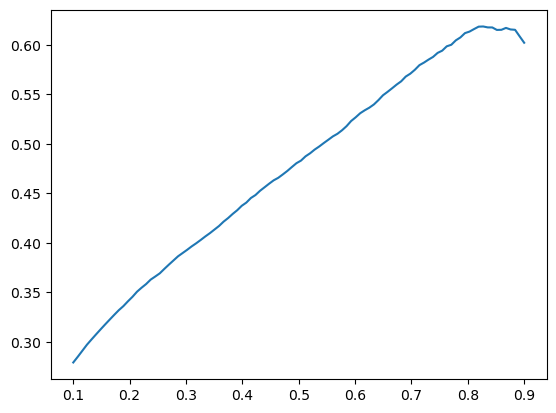

In [17]:
thresholds = np.linspace(0.1,0.9,100)

scores = [f1_score(y_test, y_prob_xgb > t) for t in thresholds]

best_t = thresholds[np.argmax(scores)]
best_f1 = max(scores)
print(scores)
print(best_f1)
plt.plot(thresholds, scores)

In [28]:
y_label_newthold = y_prob_xgb > best_t
cm_new = confusion_matrix(y_test, y_label_newthold)
print(cm_new)

[[35589  1194]
 [  832  1644]]
